In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

In [34]:
data_train, data_test = tfds.load(name='mnist', split=['train', 'test'], shuffle_files=True, as_supervised=True)

def normalize_img(image, label):
  return tf.cast(image, tf.float32) / 255., label

data_train = data_train.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
data_train = data_train.cache()
data_train = data_train.batch(128)
data_train = data_train.prefetch(tf.data.AUTOTUNE)

In [105]:
data_test = data_test.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
data_test = data_test.cache()
data_test = data_test.batch(128)
data_test = data_test.prefetch(tf.data.AUTOTUNE)

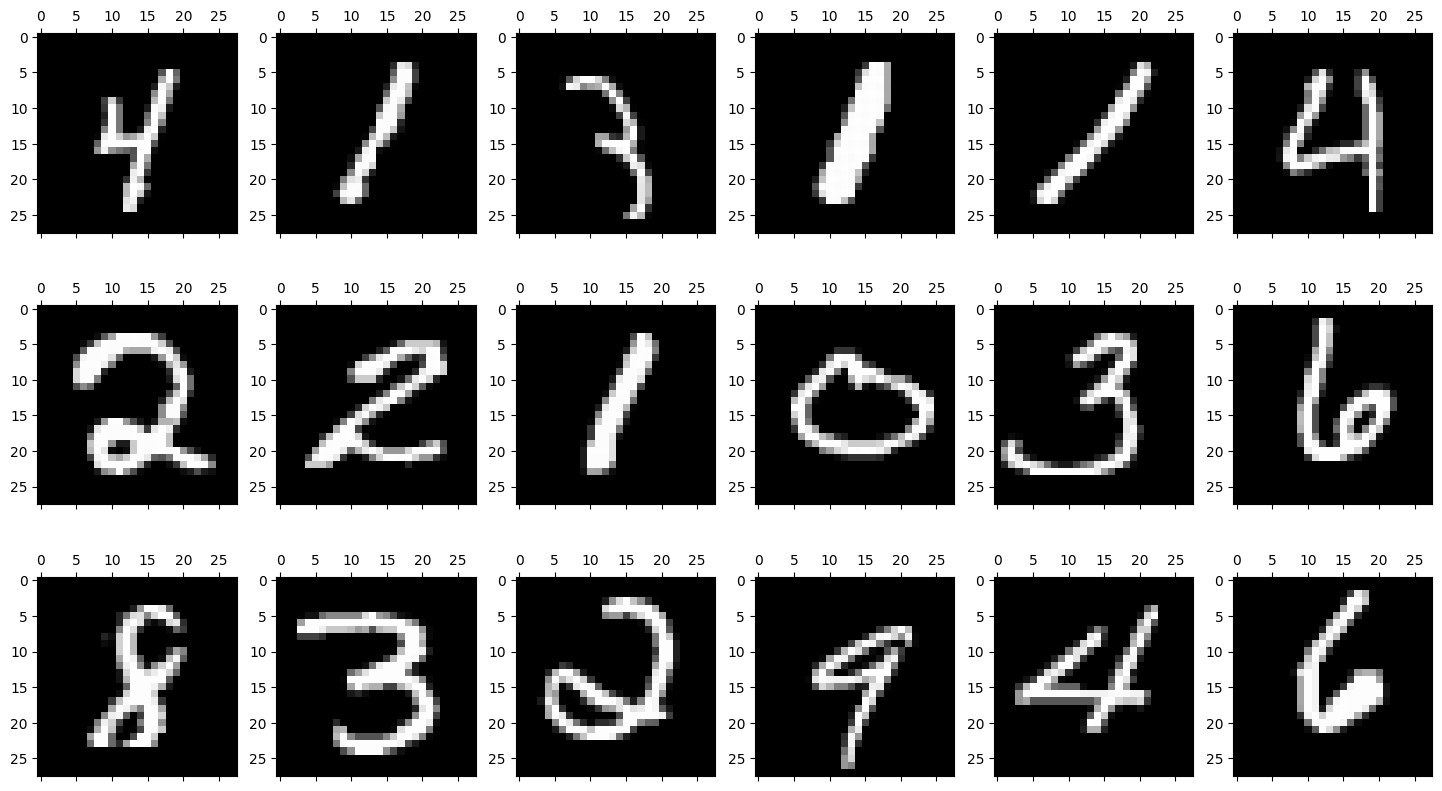

In [57]:
fig, axes = plt.subplots(3, 6, figsize=(18, 10))
axes = axes.flatten()
for sample, ax in zip(data_train.take(18), axes):
  ax.matshow(sample[0][0], cmap='gray')
plt.show()

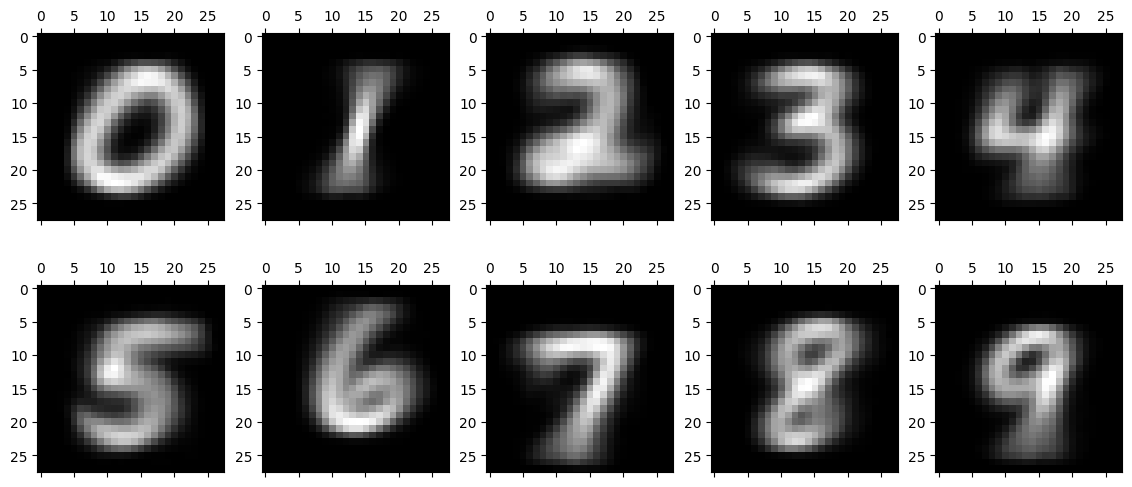

In [58]:
mean_images = [np.zeros((28, 28, 1)) for i in range(10)]

for img in data_train.as_numpy_iterator():
  for i in img[1]:
    mean_images[img[1][i]] += img[0][i]

fig, axes = plt.subplots(2, 5, figsize=(14,6))
axes = axes.flatten()
for mean, ax in zip(mean_images, axes):
  ax.matshow(mean, cmap='gray')
plt.show()

In [60]:
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Sequential

flattener = Sequential([Flatten(input_shape=(28, 28))])
flat_images = flattener.predict(data_train)

 85/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [86]:
28 * 28

784

In [85]:
flat_images.shape

(60000, 784)

In [69]:
labels = np.concatenate([y for x, y in data_train])
labels.shape

(60000,)

In [70]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(flat_images, labels)


SVC()

(1, 784)


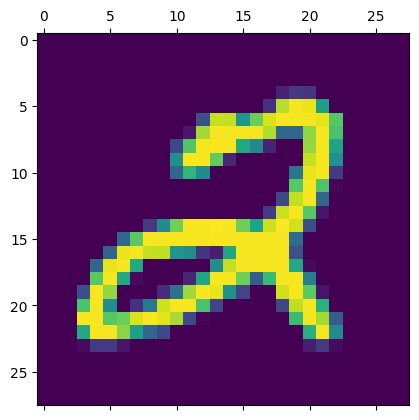

In [102]:
test_sample, = data_test.take(1)
flat_test = test_sample[0].numpy()
flat_test = flat_test.flatten()
flat_test = flat_test.reshape((1, -1))
test_label = test_sample[1].numpy()
print(flat_test.shape)
plt.matshow(test_sample[0])
plt.show()

In [103]:
svc.predict(flat_test)

array([2])

In [107]:
flat_test_images = flattener.predict(data_test)
test_labels = np.concatenate([y for x, y in data_test])
print(test_labels.shape)
print(flat_test_images.shape)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
(10000,)
(10000, 784)


In [108]:
from sklearn.metrics import accuracy_score

predictions = svc.predict(flat_test_images)
print(accuracy_score(predictions, test_labels))

0.0892


In [110]:
xxx = np.concatenate([x for x, y in data_test])
xxx.shape

(10000, 28, 28, 1)